# Exercise 1 — Point Clouds: Geometry and Spread in 2D

Runnable code for the *Data* deliverable. This notebook generates the four
Gaussian clouds, studies how a global spread factor changes their separability,
and saves every figure the report shows. All randomness comes from a single fixed
generator (`rng = np.random.default_rng(42)`) so the results are reproducible.

In [ ]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

rng = np.random.default_rng(42)

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_PER_CLASS = 100
MEANS = np.array([[2.0, 3.0], [5.0, 6.0], [8.0, 1.0], [15.0, 4.0]])
STDS = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]])
SCALES = [0.5, 1.0, 2.0, 4.0]
CLASS_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
CLASS_LABELS = [f"Class {k}" for k in range(4)]

Z = rng.standard_normal((4, N_PER_CLASS, 2))
LABELS = np.repeat(np.arange(4), N_PER_CLASS)


def make_dataset(scale: float) -> np.ndarray:
    """Return the (400, 2) point cloud for a given global spread factor."""
    clouds = MEANS[:, None, :] + (scale * STDS)[:, None, :] * Z
    return clouds.reshape(-1, 2)


datasets = {s: make_dataset(s) for s in SCALES}

## A — Generate the clouds

400 samples, 100 per class, one Gaussian per class with the given per-axis means
and standard deviations. **Figure 1** is the scatter at $s = 1$ with the class
means marked.

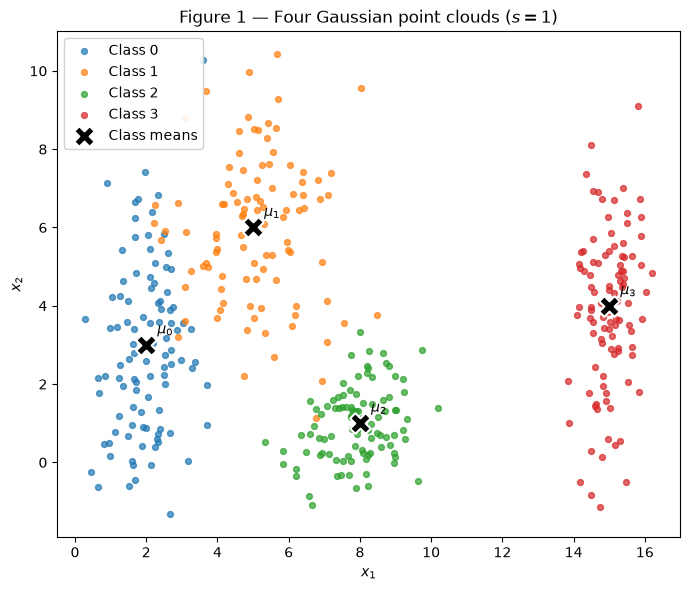

In [2]:
def figure1(points):
    fig, ax = plt.subplots(figsize=(7, 6))
    for k in range(4):
        cls = points[LABELS == k]
        ax.scatter(cls[:, 0], cls[:, 1], s=18, alpha=0.7,
                   color=CLASS_COLORS[k], label=CLASS_LABELS[k])
    ax.scatter(MEANS[:, 0], MEANS[:, 1], marker="X", s=220, c="black",
               edgecolors="white", linewidths=1.5, zorder=5, label="Class means")
    for k, (mx, my) in enumerate(MEANS):
        ax.annotate(f"$\\mu_{k}$", (mx, my), textcoords="offset points",
                    xytext=(8, 8), fontweight="bold")
    ax.set_title("Figure 1 — Four Gaussian point clouds ($s = 1$)")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc="upper left", framealpha=0.9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig1_scatter.png", dpi=150)
    return fig


figure1(datasets[1.0])
plt.show()

## B — More or less spread out

The same four classes regenerated at $s \in \{0.5, 1, 2, 4\}$ — means fixed,
only the spread scaled. **Figure 2** plots them on shared axes so the comparison
is honest.

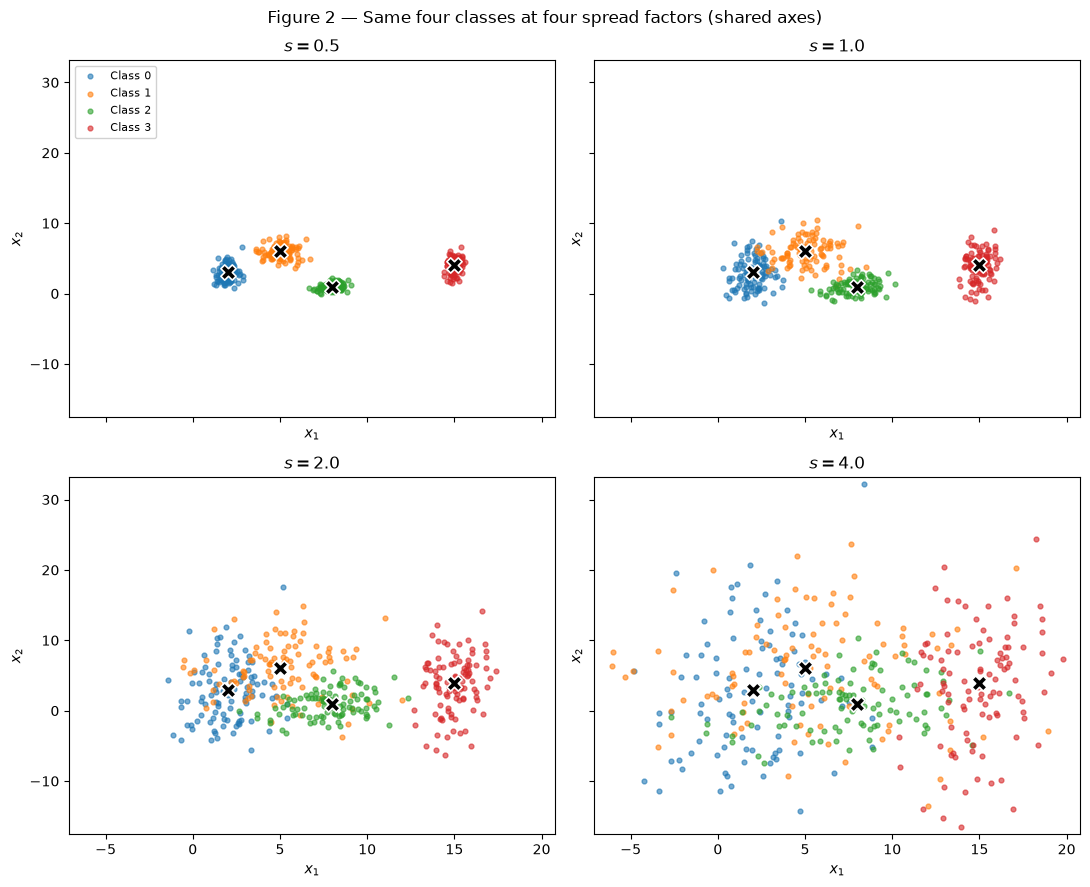

In [3]:
def figure2(datasets):
    all_pts = np.vstack(list(datasets.values()))
    pad = 1.0
    x_lim = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
    y_lim = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
    for ax, s in zip(axes.ravel(), SCALES):
        pts = datasets[s]
        for k in range(4):
            cls = pts[LABELS == k]
            ax.scatter(cls[:, 0], cls[:, 1], s=12, alpha=0.6,
                       color=CLASS_COLORS[k], label=CLASS_LABELS[k])
        ax.scatter(MEANS[:, 0], MEANS[:, 1], marker="X", s=120, c="black",
                   edgecolors="white", linewidths=1.2, zorder=5)
        ax.set_title(f"$s = {s}$")
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
    axes.ravel()[0].legend(loc="upper left", fontsize=8, framealpha=0.9)
    fig.suptitle("Figure 2 — Same four classes at four spread factors (shared axes)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_scales.png", dpi=150)
    return fig


figure2(datasets)
plt.show()

### Separation ratios $r_{ij}$ at $s = 1$

$r_{ij} = \Vert \mu_i - \mu_j \Vert / (\bar{\sigma}_i + \bar{\sigma}_j)$,
with $\bar{\sigma}_k = (\sigma_{k,x} + \sigma_{k,y})/2$. High means well
separated; low means blending.

In [4]:
import pandas as pd

sigma_bar = STDS.mean(axis=1)
rows = []
for i, j in combinations(range(4), 2):
    dist = np.linalg.norm(MEANS[i] - MEANS[j])
    r = dist / (sigma_bar[i] + sigma_bar[j])
    rows.append({"pair": f"({i}, {j})", "||mu_i - mu_j||": dist, "r_ij": r})

ratios = pd.DataFrame(rows).sort_values("r_ij").reset_index(drop=True)
smallest = ratios.iloc[0]
print(f"Smallest r_ij: pair {smallest['pair']} = {smallest['r_ij']:.4f}")
print(f"  -> at s = 2 it becomes {smallest['r_ij'] / 2:.4f} (r scales with 1/s)")
ratios.round(4)

Smallest r_ij: pair (0, 1) = 1.3258
  -> at s = 2 it becomes 0.6629 (r scales with 1/s)


,pair,||mu_i - mu_j||,r_ij
0,"(0, 1)",4.2426,1.3258
1,"(1, 2)",5.8310,2.3800
2,"(0, 2)",6.3246,2.4802
3,"(2, 3)",7.6158,3.5422
4,"(1, 3)",10.1980,3.6422
5,"(0, 3)",13.0384,4.4960


### Mixing rate per scale

Fraction of points whose nearest class **mean** is not their own class — a purely
geometric check against the four fixed means, nothing trained. **Figure 3** plots
it against $s$.

s = 0.5: mixing rate = 0.0025
s = 1.0: mixing rate = 0.0500
s = 2.0: mixing rate = 0.2025
s = 4.0: mixing rate = 0.4300


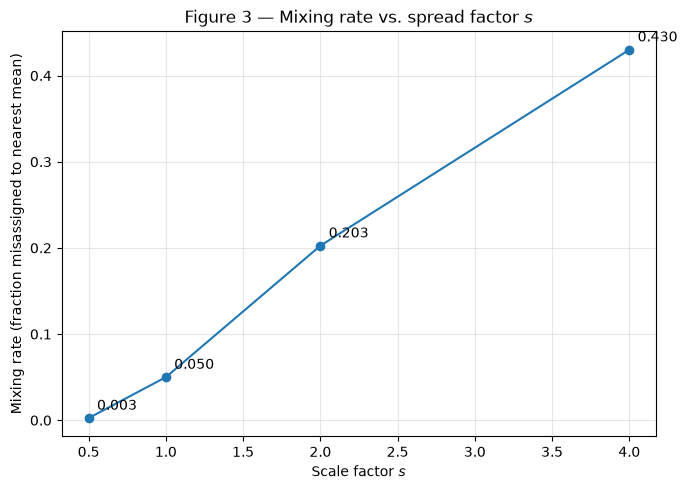

In [5]:
def mixing_rate(points):
    dists = np.linalg.norm(points[:, None, :] - MEANS[None, :, :], axis=2)
    return float(np.mean(dists.argmin(axis=1) != LABELS))


rates = {s: mixing_rate(datasets[s]) for s in SCALES}
for s, r in rates.items():
    print(f"s = {s}: mixing rate = {r:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(rates), list(rates.values()), marker="o", color="#1f77b4")
for s, r in rates.items():
    ax.annotate(f"{r:.3f}", (s, r), textcoords="offset points", xytext=(6, 6))
ax.set_title("Figure 3 — Mixing rate vs. spread factor $s$")
ax.set_xlabel("Scale factor $s$")
ax.set_ylabel("Mixing rate (fraction misassigned to nearest mean)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_mixing.png", dpi=150)
plt.show()

## C — Analysis: sketched decision boundaries

A trained network carves the plane into one region per class. The nearest-centroid
(Voronoi) partition is a good sketch of those piecewise-linear boundaries.

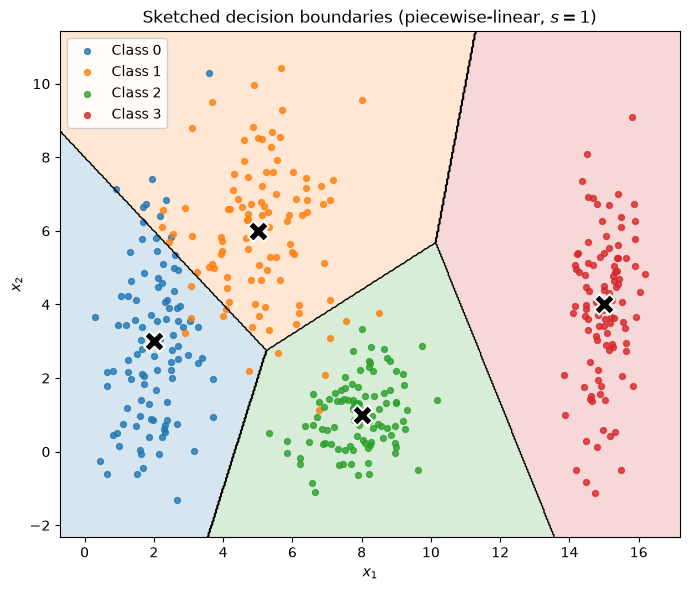

In [6]:
def figure1_boundaries(points):
    pad = 1.0
    x_min, x_max = points[:, 0].min() - pad, points[:, 0].max() + pad
    y_min, y_max = points[:, 1].min() - pad, points[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    grid = np.c_[xx.ravel(), yy.ravel()]
    gdist = np.linalg.norm(grid[:, None, :] - MEANS[None, :, :], axis=2)
    regions = gdist.argmin(axis=1).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(xx, yy, regions, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
                colors=CLASS_COLORS, alpha=0.18)
    ax.contour(xx, yy, regions, levels=[0.5, 1.5, 2.5], colors="black", linewidths=1.0)
    for k in range(4):
        cls = points[LABELS == k]
        ax.scatter(cls[:, 0], cls[:, 1], s=18, alpha=0.8,
                   color=CLASS_COLORS[k], label=CLASS_LABELS[k])
    ax.scatter(MEANS[:, 0], MEANS[:, 1], marker="X", s=220, c="black",
               edgecolors="white", linewidths=1.5, zorder=5)
    ax.set_title("Sketched decision boundaries (piecewise-linear, $s = 1$)")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc="upper left", framealpha=0.9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig1_boundaries.png", dpi=150)
    return fig


figure1_boundaries(datasets[1.0])
plt.show()